## Notebook setup

In [1]:
from pathlib import Path
import sys

sys.path.insert(0, str(Path.cwd().parent / "src"))

from format_umap import format_umap_legend

In [2]:
import logging, warnings;
warnings.filterwarnings("ignore")

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd
import re
from pathlib import Path 

import warnings, scipy.sparse as sp, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.pyplot import rc_context
import matplotlib.font_manager
import matplotlib.lines as lines


pd.set_option('display.max_rows', 200)

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['font.family'] = 'sans-serif'
matplotlib.rcParams['font.sans-serif'] = 'Arial'
matplotlib.rc('font', size=12)

sc.settings.n_jobs=-1
sc.set_figure_params(dpi=80, dpi_save=300, color_map='Spectral_r', vector_friendly=True, transparent=True)
sc.settings.figdir = '../output/figures/'
sc.settings.verbosity = 1 # verbosity: errors (0), warnings (1), info (2), hints (3)
sc.logging.print_header()

%matplotlib inline 
%config InlineBackend.figure_format = 'retina'

In [3]:
user_defined_palette =  [ '#F6222E', '#FEAF16','#3283FE','#BDCDFF', '#3B00FB', '#F8A19F', '#1CFFCE',  '#C4451C', 
                          '#2ED9FF', '#c1c119', '#8b0000', '#FE00FA', '#1CBE4F','#B5EFB5', '#0e452b', '#AA0DFE']

In [4]:
user_defined_cmap_markers = LinearSegmentedColormap.from_list('mycmap', ["#E6E6FF", "#CCCCFF", "#B2B2FF", "#9999FF",  "#6666FF",   "#3333FF", "#0000FF"])
user_defined_cmap_degs = LinearSegmentedColormap.from_list('mycmap', ["#0000FF", "#3333FF", "#6666FF", "#9999FF", "#B2B2FF", "#CCCCFF", "#E6E6FF", "#E6FFE6", "#CCFFCC", "#B2FFB2", "#99FF99", "#66FF66", "#33FF33", "#00FF00"])

In [5]:
path_to_h5ad = '../data/GSE244673_CD45pos_thymic_RAG2-CD45+cells_all+annotation.h5ad'

In [6]:
adata = sc.read_h5ad(path_to_h5ad)

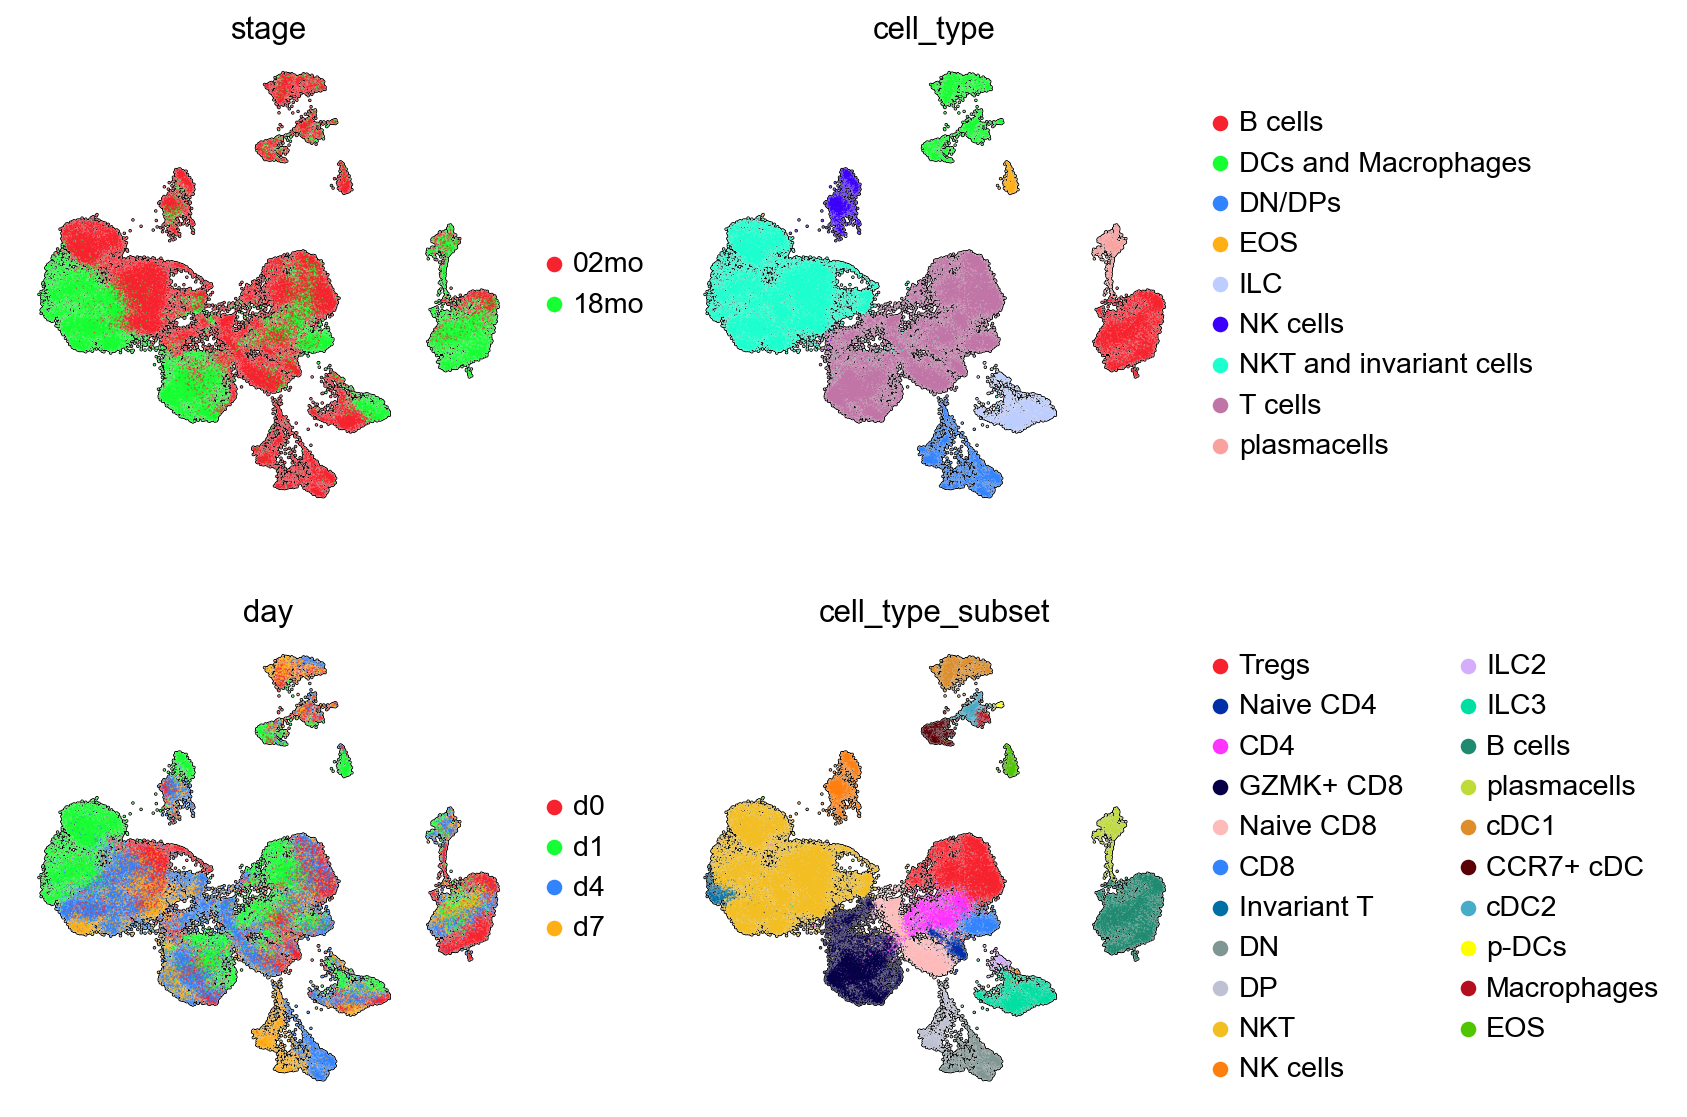

In [7]:
sc.set_figure_params(dpi=80, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)

sc.pl.umap(
    adata, 
    color=['stage', 'cell_type',  'day', 'cell_type_subset'], 
    color_map='Spectral_r', 
    use_raw=False,
    ncols=2,
    wspace = 0.2,
    outline_width=[0.6, 0.05],
    frameon=False,
    add_outline=True,
    sort_order = True,
    vmax='p99')

In [8]:
DCs = adata[(adata.obs['cell_type']=='DCs and Macrophages') & (adata.obs['stage']=='02mo') & (adata.obs['cell_type_subset']!='Macrophages') & (adata.obs['cell_type_subset']!='p-DCs')]

In [9]:
sc.pp.filter_genes(DCs, min_cells=1) # remove columns with all 0s

In [10]:
sc.pp.highly_variable_genes(DCs, n_top_genes=1000, n_bins=20, flavor='seurat', inplace=True, batch_key='day')

In [11]:
DCs.uns['cell_type_subset_colors'] = ['#F6222E', '#B5EFB5', '#AA0DFE']
DCs.uns['day_colors'] = ['#0080FF',  '#FF00FF',  '#FFA500',  '#00D6D8']

In [12]:
DCs.obs["cell_type_subset"] = DCs.obs["cell_type_subset"].replace({"CCR7+ cDC": "DC:aDC",
                                                                       "cDC1": "DC:cDC1",
                                                                       "cDC2": "DC:cDC2"})
DCs.obs["day"] = DCs.obs["day"].replace({"d0": "Steady State",
                                                      "d1": "D1",
                                                      "d4": "D4",
                                                      "d7": "D7"})

# Define desired order

order = ["DC:aDC", "DC:cDC1", "DC:cDC2"]

DCs.obs["cell_type_subset"] = DCs.obs["cell_type_subset"].astype("category").cat.reorder_categories(order, ordered=True)

In [13]:
for n_comps in [5]:
    rng = np.random.RandomState(42)
    sc.tl.pca(DCs, n_comps=n_comps, svd_solver='arpack', random_state=rng, use_highly_variable=True)
   # sce.pp.harmony_integrate(DCs, 'day')
    sc.pp.neighbors(DCs, n_neighbors=15, use_rep='X_pca', random_state=rng)
    sc.tl.umap(DCs)

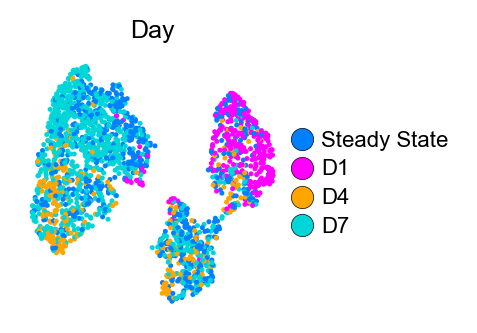

In [14]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)

color = "day"
size = 13
title = "Day"

ax = sc.pl.umap(
    DCs,
    color=color, # <- HERE
    frameon=False,
    show=False,
    size=size, # <- HERE
    use_raw= False
)

ax.set_title(title, fontsize=9) # <- HERE

format_umap_legend(
    ax
)

fig = ax.figure

fig.set_size_inches(1.7, 1.7) # <- HERE

fig.savefig(
    "UMAP_day.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

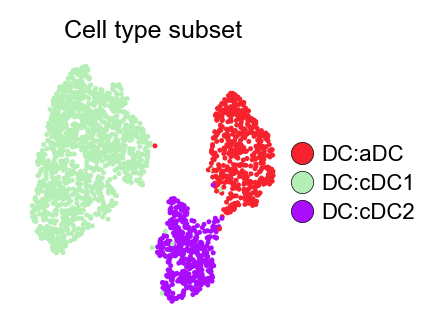

In [15]:
sc.set_figure_params(dpi=100, dpi_save=300, color_map='viridis', vector_friendly=True, transparent=True)

color = "cell_type_subset"
size = 13
title = "Cell type subset"

ax = sc.pl.umap(
    DCs,
    color=color, # <- HERE
    frameon=False,
    show=False,
    size=size, # <- HERE
    use_raw= False
)

ax.set_title(title, fontsize=9) # <- HERE

format_umap_legend(
    ax
)

fig = ax.figure

fig.set_size_inches(1.7, 1.7) # <- HERE

fig.savefig(
    "UMAP_cell_type_subset.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True,
)

plt.show()

In [16]:
DCs.obs['distinct'] = ''
DCs.obs['distinct'] = DCs.obs[['day', 'cell_type_subset']].agg(' '.join, axis=1)

DCs.uns['distinct_colors'] = ['#F6222E', '#B5EFB5', '#AA0DFE',
                              '#F6222E', '#B5EFB5', '#AA0DFE',
                              '#F6222E', '#B5EFB5', '#AA0DFE',
                              '#F6222E', '#B5EFB5', '#AA0DFE']

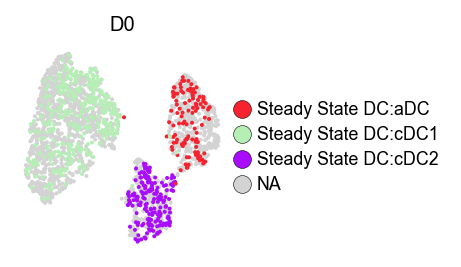

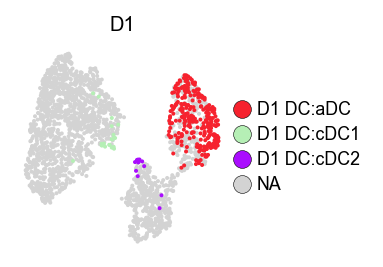

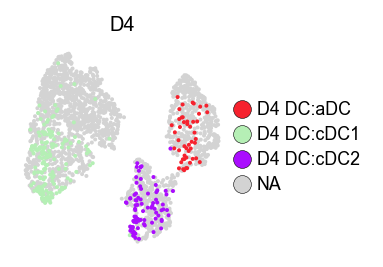

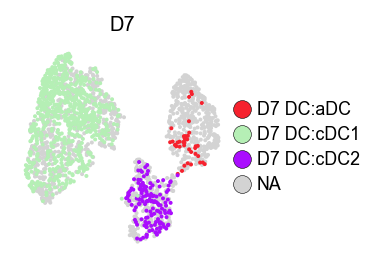

In [17]:
sc.set_figure_params(
    dpi=80,
    dpi_save=300,
    color_map="viridis",
    vector_friendly=True,
    transparent=True,
)

plots = {
    "d0": ["Steady State DC:aDC", "Steady State DC:cDC1", "Steady State DC:cDC2"],
    "d1": ["D1 DC:aDC", "D1 DC:cDC1", "D1 DC:cDC2"],
    "d4": ["D4 DC:aDC", "D4 DC:cDC1", "D4 DC:cDC2"],
    "d7": ["D7 DC:aDC", "D7 DC:cDC1", "D7 DC:cDC2"],
}

for label, groups in plots.items():

    ax = sc.pl.umap(
        DCs,
        color="distinct",
        groups=groups,
        color_map="Spectral_r",
        use_raw=False,
        size=13,
        wspace=0.1,
        outline_width=[0.6, 0.05],
        frameon=False,
        add_outline=False,
        show=False,
    )

    ax.set_title(label.upper(), fontsize=9)

    format_umap_legend(ax)

    fig = ax.figure
    fig.set_size_inches(1.7, 1.7)

    fig.savefig(
        f"UMAP_DCs_{label}.pdf",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()

In [18]:
crosstb = pd.crosstab(DCs.obs['day'], DCs.obs['cell_type_subset'], normalize='index')

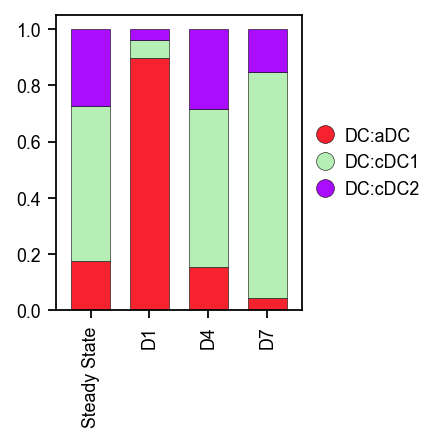

In [19]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
with rc_context({'figure.figsize': (3, 3)}):
    ax = crosstb.plot(
        kind='bar', 
        stacked=True, 
        width=0.67, 
        color=DCs.uns['cell_type_subset_colors'],
        legend=True, 
        edgecolor='black',
        linewidth=0.25
    )

    handles, labels = ax.get_legend_handles_labels()
    circle_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=h.patches[0].get_facecolor(),
                         markeredgecolor='black', markersize=8, markeredgewidth=0.25) for h in handles]
    ax.legend(circle_handles[::], labels[::], loc='center left',
              bbox_to_anchor=(1.01, 0.5), prop={'size':8},
              ncol=1, frameon=False, handletextpad=0.9)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=8)
    plt.tight_layout()
    plt.savefig('../output/figures/frac_barplot_dc_cell_type_subset(v).pdf', dpi=300, bbox_inches='tight', transparent=True)
 

In [20]:
crosstb = pd.crosstab(DCs.obs['day'], DCs.obs['cell_type_subset'])

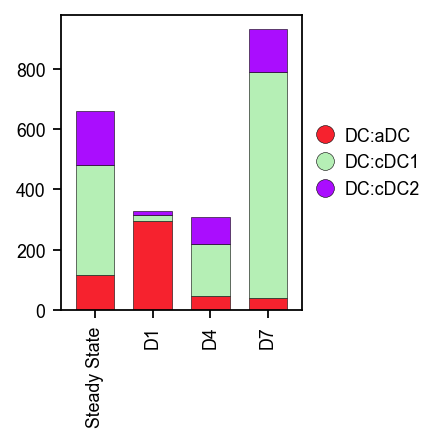

In [21]:
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
with rc_context({'figure.figsize': (3, 3)}):
    ax = crosstb.plot(
        kind='bar', 
        stacked=True, 
        width=0.67, 
        color=DCs.uns['cell_type_subset_colors'],
        legend=True, 
        edgecolor='black',
        linewidth=0.25
    )

    handles, labels = ax.get_legend_handles_labels()
    circle_handles = [Line2D([0], [0], marker='o', color='w', markerfacecolor=h.patches[0].get_facecolor(),
                         markeredgecolor='black', markersize=8, markeredgewidth=0.25) for h in handles]
    ax.legend(circle_handles[::], labels[::], loc='center left',
              bbox_to_anchor=(1.01, 0.5), prop={'size':8},
              ncol=1, frameon=False, handletextpad=0.9)
    ax.grid(False)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis='both', labelsize=8)
    plt.tight_layout()
    plt.savefig('../output/figures/frac_barplot_dc_cell_type_subset(v)(numbers).pdf', dpi=300, bbox_inches='tight', transparent=True)
 

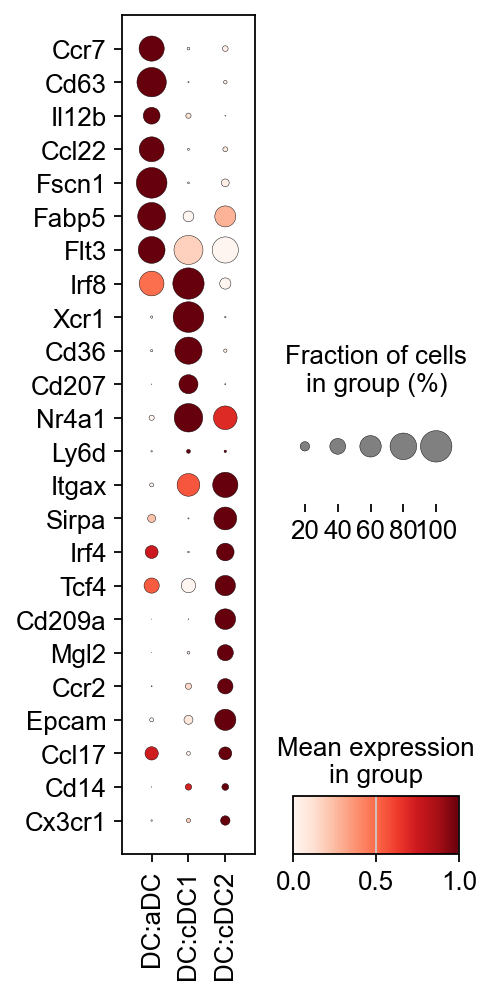

In [22]:
sc.pl.dotplot(DCs, [ 'Ccr7', 'Cd63', 'Il12b', 'Ccl22', 'Fscn1', 'Fabp5', 'Flt3', 'Irf8','Xcr1', 'Cd36', 'Cd207', 'Nr4a1', 'Ly6d', 'Itgax', 'Sirpa', 'Irf4', 'Tcf4', 'Cd209a', 'Mgl2', 'Ccr2', 'Epcam', 'Ccl17', 'Cd14', 'Cx3cr1',], groupby='cell_type_subset', standard_scale='var', figsize=(2.7,6.9), swap_axes=True, use_raw=False, save='_DC-markers.pdf')

# Integration with the new manuscript data

In [23]:
path_to_h5ad = '../data/PARABIOSIS_DC.h5ad'

In [24]:
adata = sc.read_h5ad(path_to_h5ad)

In [25]:
DCs_new = adata[(adata.obs['cell_type_subset']=='DC:aDC') | 
                (adata.obs['cell_type_subset']=='DC:cDC1') |
                (adata.obs['cell_type_subset']=='DC:cDC2') ].copy()

In [26]:
DC_combined = sc.concat([DCs, DCs_new], merge='same', join='outer', label='experiment',  keys=['public', 'parabiosis'])

In [27]:
DC_combined.uns['cell_type_subset_colors'] = ['#F6222E', '#B5EFB5', '#AA0DFE']
DC_combined.uns['day_colors'] = ['#0080FF',  '#FF00FF',  '#FFA500',  '#00D6D8']
DC_combined.uns['experiment_colors'] = [ '#D9AE61', '#ba005a']
DC_combined.uns['condition_colors'] = ['#A2DA3CFF', '#C12A45FF', '#8B4F82FF', '#44486DFF']

In [28]:
sc.pp.highly_variable_genes(DC_combined, n_top_genes=2000, n_bins=20, flavor='seurat', inplace=True)

In [29]:
for n_comps in [5]:
    rng = np.random.RandomState(42)
    sc.tl.pca(DC_combined, n_comps=n_comps, svd_solver='arpack', random_state=rng, use_highly_variable=True)
    sce.pp.harmony_integrate(DC_combined, 'experiment')
    sc.pp.neighbors(DC_combined, n_neighbors=15, use_rep='X_pca_harmony', random_state=rng)
    sc.tl.umap(DC_combined)

2026-09-03 21:20:22,530 - harmonypy - INFO - Iteration 1 of 10
2026-09-03 21:20:22,645 - harmonypy - INFO - Iteration 2 of 10
2026-09-03 21:20:22,758 - harmonypy - INFO - Iteration 3 of 10
2026-09-03 21:20:22,874 - harmonypy - INFO - Iteration 4 of 10
2026-09-03 21:20:22,974 - harmonypy - INFO - Iteration 5 of 10
2026-09-03 21:20:23,059 - harmonypy - INFO - Converged after 5 iterations


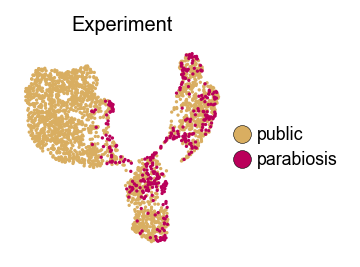

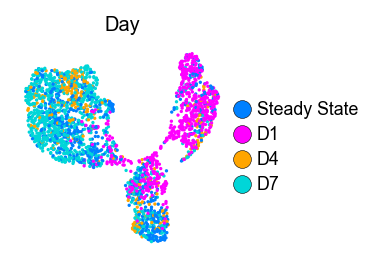

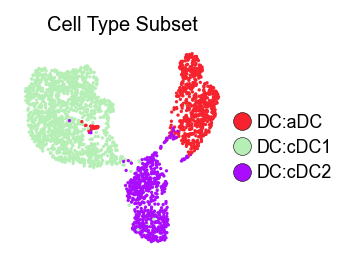

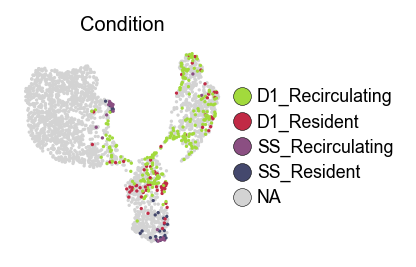

In [30]:
sc.set_figure_params(
    dpi=80,
    dpi_save=300,
    color_map="viridis",
    vector_friendly=True,
    transparent=True,
)

for color, title in [
    ("experiment", "Experiment"),
    ("day", "Day"),
    ("cell_type_subset", "Cell Type Subset"),
    ("condition", "Condition"),
]:

    ax = sc.pl.umap(
        DC_combined,
        color=color,
        color_map="Spectral_r",
        use_raw=False,
        size=9,
        outline_width=[0.6, 0.05],
        frameon=False,
        add_outline=False,
        sort_order=True,
        vmax="p99",
        show=False,
    )

    ax.set_title(title, fontsize=9)

    if ax.get_legend() is not None:
        format_umap_legend(ax)

    fig = ax.figure
    fig.set_size_inches(1.7, 1.7)

    fig.savefig(
        f"UMAP_{color}_merged.pdf",
        dpi=300,
        bbox_inches="tight",
        transparent=True,
    )

    plt.show()

## Subset for only day 1 DCs

In [31]:
DCs_D1 = DCs[DCs.obs['day']=='D1'].copy()

In [32]:
sc.tl.rank_genes_groups(DCs_D1, 
                        'cell_type_subset', 
                        groups=['DC:aDC'],
                        reference='rest',
                        method='wilcoxon', 
                        use_raw=False)

In [33]:
result = DCs_D1.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
        for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']})

Looks like you are using a tranform that doesn't support FancyArrowPatch, using ax.annotate instead. The arrows might strike through texts. Increasing shrinkA in arrowprops might help.


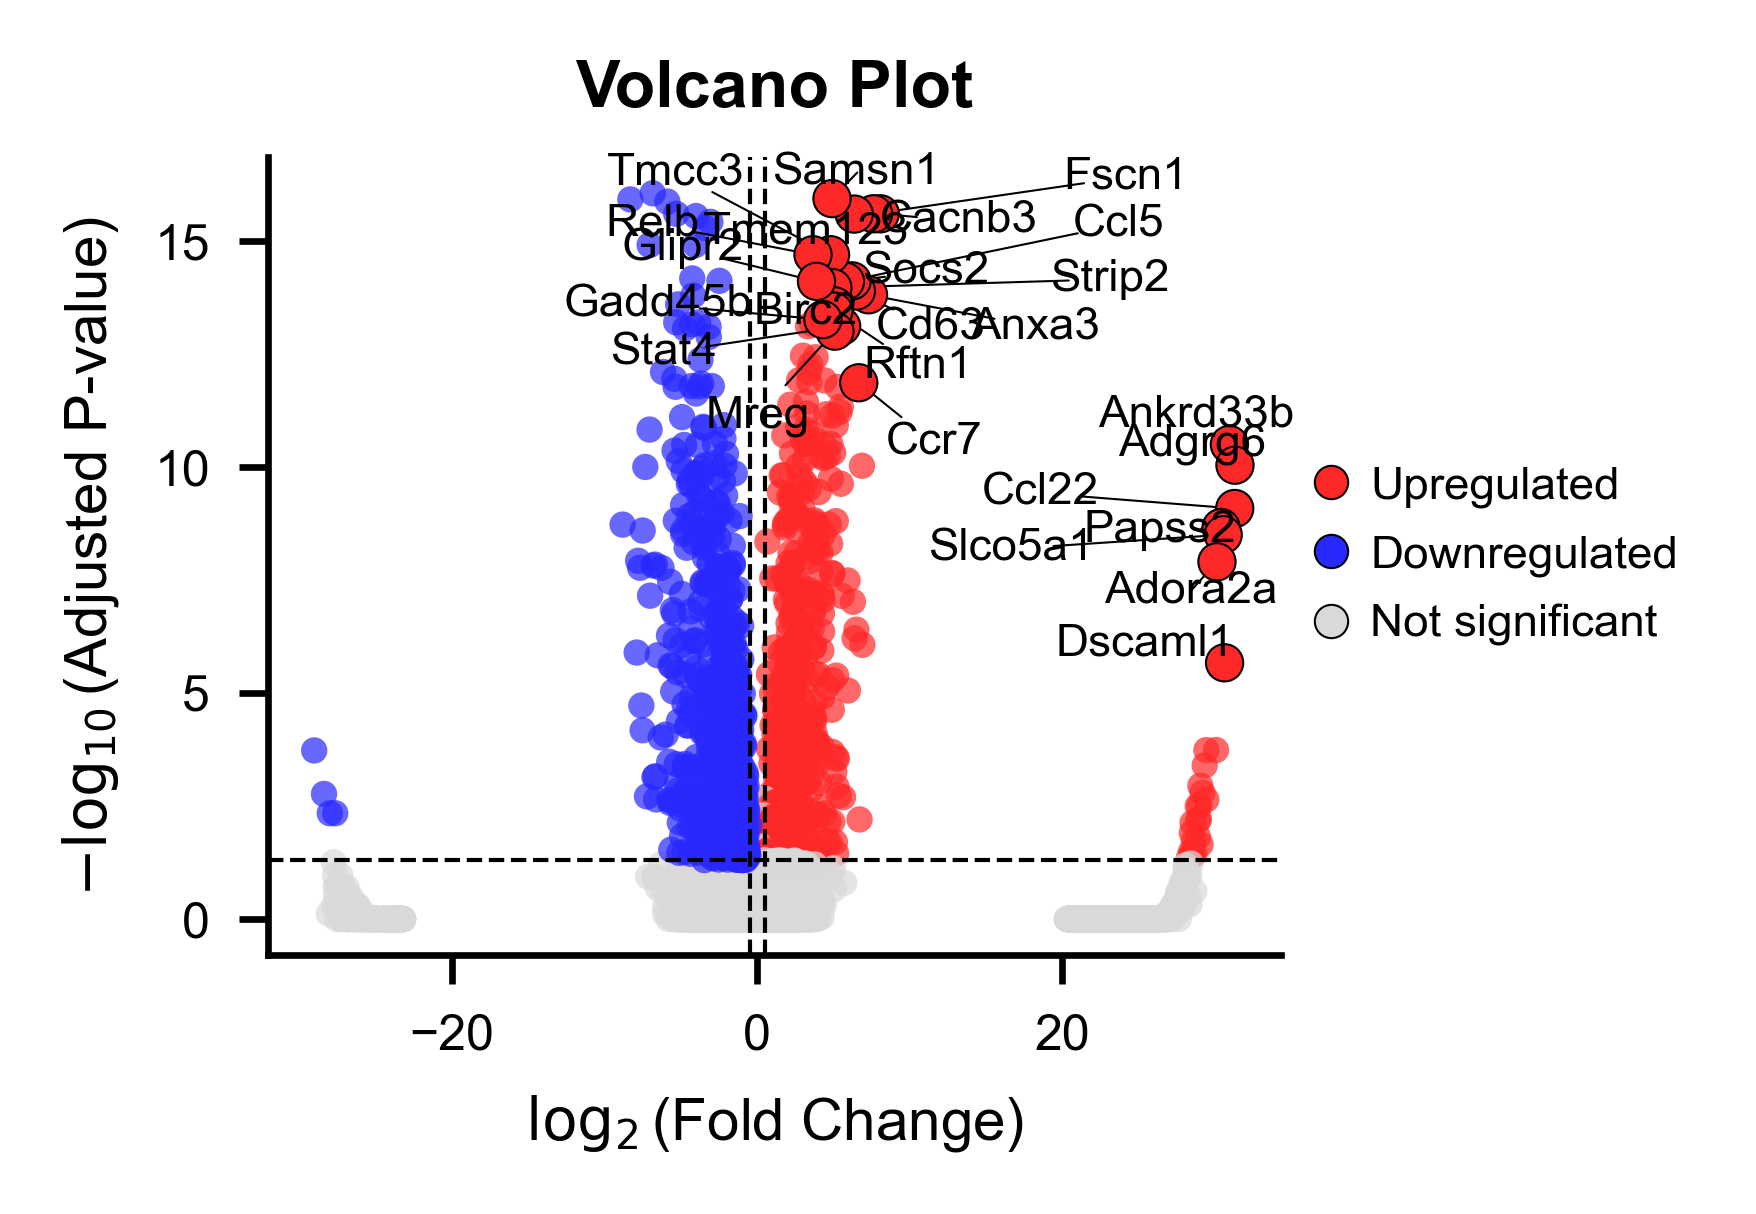

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D

# -----------------------------
# Parameters
# -----------------------------
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 25

TITLE = "Volcano Plot"

# -----------------------------
# Column names
# -----------------------------
name_col = "DC:aDC_n"
lfc_col = "DC:aDC_l"
pval_col = "DC:aDC_p"

# -----------------------------
# Colors
# -----------------------------
bwr = plt.get_cmap("bwr")

from matplotlib.colors import to_hex

color_up = to_hex(bwr(0.92))
color_down = to_hex(bwr(0.08))
color_ns = "#D9D9D9"

# -----------------------------
# Prepare data
# -----------------------------
plot_df = df.dropna(
    subset=[lfc_col, pval_col]
).copy()

plot_df["neglog10p"] = -np.log10(
    plot_df[pval_col].clip(lower=1e-300)
)

plot_df["sig"] = (
    (plot_df[lfc_col].abs() >= LFC_CUTOFF)
    & (plot_df[pval_col] < PVAL_CUTOFF)
)

# -----------------------------
# Assign colors
# -----------------------------
plot_df["color"] = color_ns

plot_df.loc[
    plot_df["sig"] & (plot_df[lfc_col] > 0),
    "color"
] = color_up

plot_df.loc[
    plot_df["sig"] & (plot_df[lfc_col] < 0),
    "color"
] = color_down

# -----------------------------
# Select genes to label
# -----------------------------
sig_df = plot_df[
    plot_df["sig"]
].copy()

sig_df["score"] = (
    sig_df["neglog10p"]
    * np.sqrt(np.abs(sig_df[lfc_col]))
)

up_df = sig_df[
    sig_df[lfc_col] > 0
]

label_df = (
    up_df
    .nlargest(N_LABELS, "score")
    .drop_duplicates()
)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(
    figsize=(2.5, 2.25),
    dpi=300
)

# All genes
ax.scatter(
    plot_df[lfc_col],
    plot_df["neglog10p"],
    c=plot_df["color"],
    s=10,
    alpha=0.7,
    linewidths=0,
    rasterized=True,
    zorder=1
)

# Highlighted genes
ax.scatter(
    label_df[lfc_col],
    label_df["neglog10p"],
    s=20,
    c=label_df["color"],
    edgecolors="black",
    linewidths=0.25,
    zorder=5
)

# Threshold lines
ax.axvline(
    LFC_CUTOFF,
    color="black",
    linestyle="--",
    linewidth=0.5
)

ax.axvline(
    -LFC_CUTOFF,
    color="black",
    linestyle="--",
    linewidth=0.5
)

ax.axhline(
    -np.log10(PVAL_CUTOFF),
    color="black",
    linestyle="--",
    linewidth=0.5
)

# Labels
texts = []

for _, row in label_df.iterrows():

    texts.append(
        ax.text(
            row[lfc_col],
            row["neglog10p"],
            str(row[name_col]),
            fontsize=5.5,
            zorder=10
        )
    )

adjust_text(
    texts,
    ax=ax,
    force_points=(7, 7),
    force_text=(7, 7),
    expand_points=(7, 7),
    expand_text=(7, 7),
    lim=1000,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        lw=0.25,
        shrinkA=5,
        shrinkB=2
    )
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    TITLE,
    fontsize=8,
    fontweight="bold"
)

ax.set_xlabel(
    r"$\log_2$(Fold Change)",
    fontsize=7
)

ax.set_ylabel(
    r"$-\log_{10}$(Adjusted P-value)",
    fontsize=7
)

ax.tick_params(
    labelsize=6
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# -----------------------------
# Legend
# -----------------------------
legend_elements = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_up,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Upregulated"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_down,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Downregulated"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_ns,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Not significant"
    )
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=5.5,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    handletextpad=0.6,
    labelspacing=0.6
)


# -----------------------------
# Save
# -----------------------------
plt.tight_layout()
plt.subplots_adjust(right=0.9)

plt.savefig(
    "volcano_plot_D1aDCs_vs_D1othersubsets.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

plt.show()

## Subset for only aDCs

In [65]:
aDCs = DC_combined[DC_combined.obs['cell_type_subset']=='DC:aDC'].copy()

In [66]:
sc.tl.rank_genes_groups(aDCs, 
                        'day', 
                        groups=['D1'],
                        reference='rest',
                        method='wilcoxon', 
                        use_raw=False)

In [67]:
result = aDCs.uns['rank_genes_groups']
groups = result['names'].dtype.names
df = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
        for group in groups for key in ['names', 'scores', 'logfoldchanges', 'pvals_adj']})

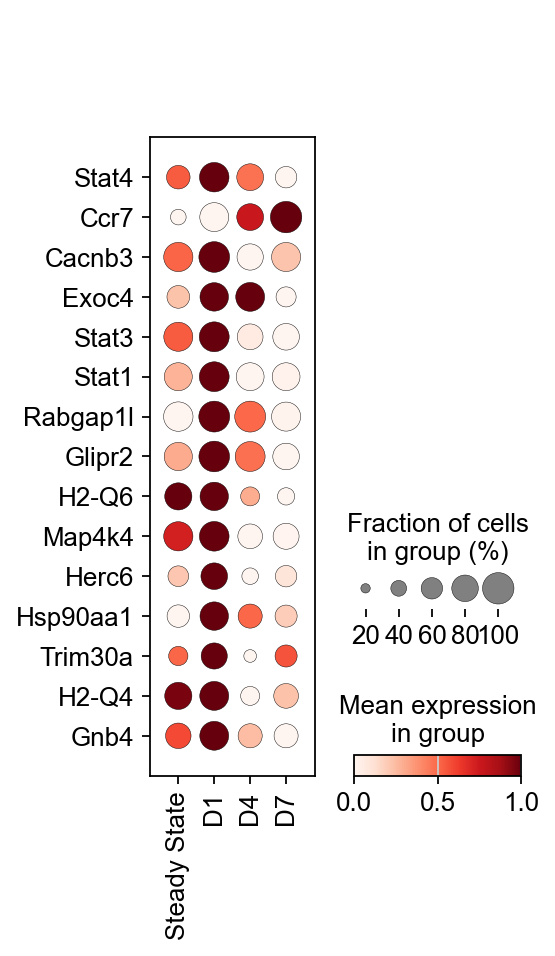

In [68]:
sc.pl.dotplot(aDCs, df.head(15).D1_n.values, groupby='day', standard_scale='var', swap_axes=True, use_raw=False, save='top15markers_aDC_D1_vs_rest.pdf')

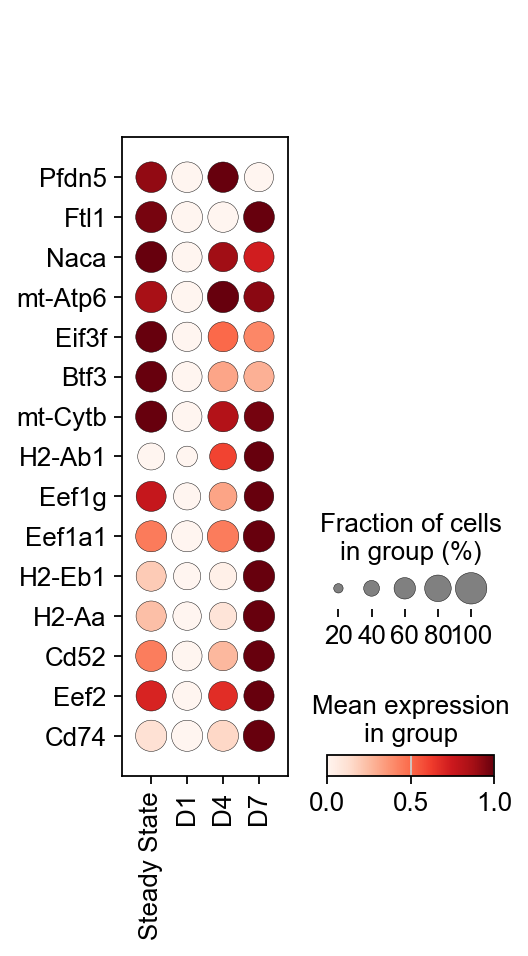

In [69]:
sc.pl.dotplot(aDCs, df.tail(15).D1_n.values, groupby='day', standard_scale='var', swap_axes=True, use_raw=False, save='bottom15markers_aDC_D1_vs_rest.pdf')

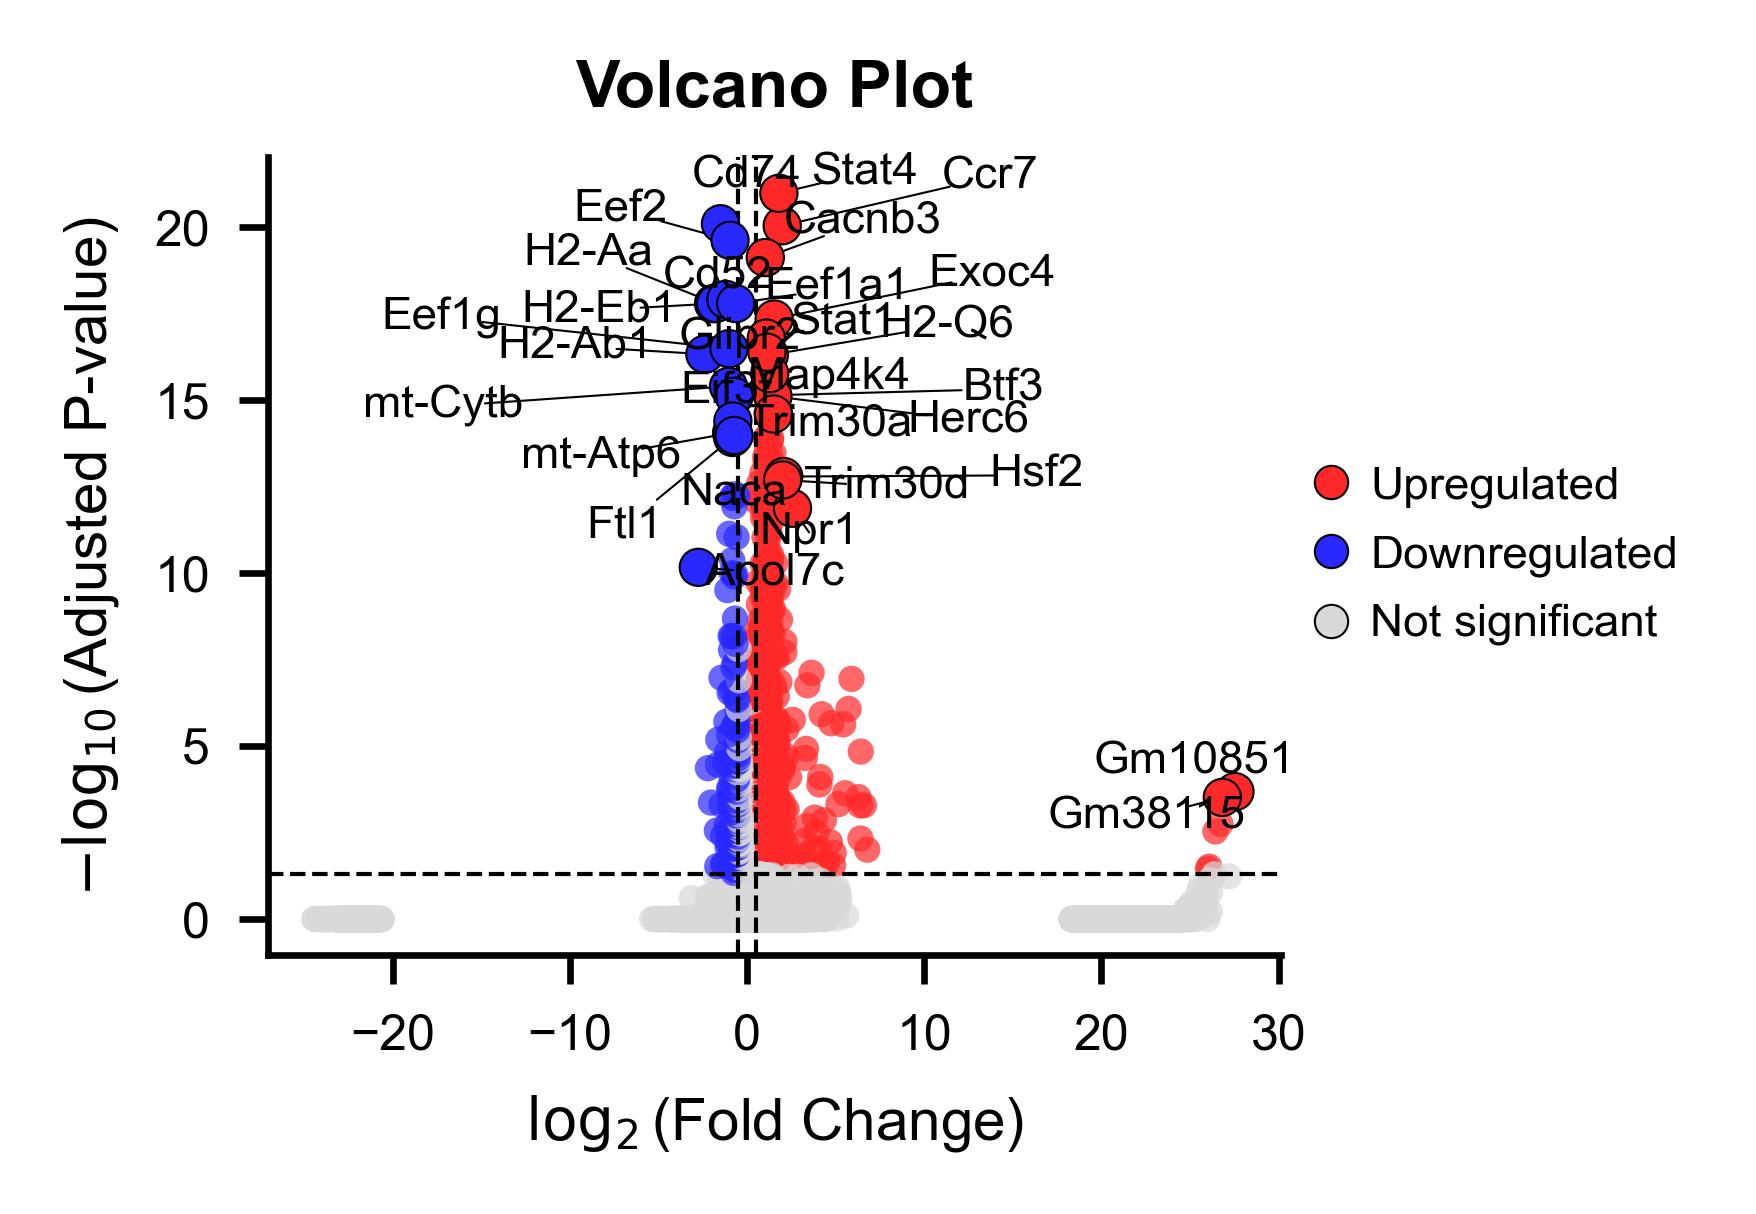

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
from matplotlib.lines import Line2D
from matplotlib.colors import to_hex

# -----------------------------
# Parameters
# -----------------------------
LFC_CUTOFF = 0.5
PVAL_CUTOFF = 0.05
N_LABELS = 15

TITLE = "Volcano Plot"

# -----------------------------
# Column names
# -----------------------------
name_col = "D1_n"
lfc_col = "D1_l"
pval_col = "D1_p"

# -----------------------------
# Colors
# -----------------------------
bwr = plt.get_cmap("bwr")

color_up = to_hex(bwr(0.92))
color_down = to_hex(bwr(0.08))
color_ns = "#D9D9D9"

# -----------------------------
# Prepare data
# -----------------------------
plot_df = df.dropna(
    subset=[lfc_col, pval_col]
).copy()

plot_df["neglog10p"] = -np.log10(
    plot_df[pval_col].clip(lower=1e-300)
)

plot_df["sig"] = (
    (plot_df[lfc_col].abs() >= LFC_CUTOFF)
    & (plot_df[pval_col] < PVAL_CUTOFF)
)

# -----------------------------
# Assign colors
# -----------------------------
plot_df["color"] = color_ns

plot_df.loc[
    plot_df["sig"] & (plot_df[lfc_col] > 0),
    "color"
] = color_up

plot_df.loc[
    plot_df["sig"] & (plot_df[lfc_col] < 0),
    "color"
] = color_down

# -----------------------------
# Select genes to label
# -----------------------------
sig_df = plot_df[
    plot_df["sig"]
].copy()

sig_df["score"] = (
    sig_df["neglog10p"]
    * np.sqrt(np.abs(sig_df[lfc_col]))
)

up_df = sig_df[
    sig_df[lfc_col] > 0
]

down_df = sig_df[
    sig_df[lfc_col] < 0
]

# Top 15 up and top 15 down
label_df = pd.concat([
    up_df.nlargest(N_LABELS, "score"),
    down_df.nlargest(N_LABELS, "score")
]).drop_duplicates()

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(
    figsize=(2.5, 2.25),
    dpi=300
)

# All genes
ax.scatter(
    plot_df[lfc_col],
    plot_df["neglog10p"],
    c=plot_df["color"],
    s=10,
    alpha=0.7,
    linewidths=0,
    rasterized=True,
    zorder=1
)

# Highlighted genes
ax.scatter(
    label_df[lfc_col],
    label_df["neglog10p"],
    s=20,
    c=label_df["color"],
    edgecolors="black",
    linewidths=0.25,
    zorder=5
)

# -----------------------------
# Threshold lines
# -----------------------------
ax.axvline(
    LFC_CUTOFF,
    color="black",
    linestyle="--",
    linewidth=0.5
)

ax.axvline(
    -LFC_CUTOFF,
    color="black",
    linestyle="--",
    linewidth=0.5
)

ax.axhline(
    -np.log10(PVAL_CUTOFF),
    color="black",
    linestyle="--",
    linewidth=0.5
)

# -----------------------------
# Labels
# -----------------------------
texts = []

for _, row in label_df.iterrows():

    texts.append(
        ax.text(
            row[lfc_col],
            row["neglog10p"],
            str(row[name_col]),
            fontsize=5.5,
            zorder=10
        )
    )

adjust_text(
    texts,
    ax=ax,
    force_points=(7, 7),
    force_text=(7, 7),
    expand_points=(7, 7),
    expand_text=(7, 7),
    lim=1000,
    arrowprops=dict(
        arrowstyle="-",
        color="black",
        lw=0.25,
        shrinkA=5,
        shrinkB=2
    )
)

# -----------------------------
# Formatting
# -----------------------------
ax.set_title(
    TITLE,
    fontsize=8,
    fontweight="bold"
)

ax.set_xlabel(
    r"$\log_2$(Fold Change)",
    fontsize=7
)

ax.set_ylabel(
    r"$-\log_{10}$(Adjusted P-value)",
    fontsize=7
)

ax.tick_params(
    labelsize=6
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.grid(False)

# -----------------------------
# Legend
# -----------------------------
legend_elements = [

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_up,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Upregulated"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_down,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Downregulated"
    ),

    Line2D(
        [0], [0],
        marker="o",
        linestyle="None",
        markerfacecolor=color_ns,
        markeredgecolor="black",
        markeredgewidth=0.25,
        markersize=4,
        label="Not significant"
    )
]

ax.legend(
    handles=legend_elements,
    frameon=False,
    fontsize=5.5,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    borderaxespad=0,
    handletextpad=0.6,
    labelspacing=0.6
)

# -----------------------------
# Save
# -----------------------------
plt.tight_layout()
plt.subplots_adjust(right=0.90)

plt.savefig(
    "volcano_plot_aDC_D1_vs_rest.pdf",
    bbox_inches="tight",
    dpi=300,
    transparent=True
)

plt.show()

## DC subset mouse signatures (at steady state)

In [41]:
DC_combined_ss = DC_combined[DC_combined.obs['day']=='Steady State'].copy()

In [42]:
sc.tl.rank_genes_groups(DC_combined_ss, 
                        'cell_type_subset', 
                        method='wilcoxon', 
                        use_raw=False)

In [43]:
result = DC_combined_ss.uns['rank_genes_groups']
groups = result['names'].dtype.names
pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
        for group in groups for key in ['names']}).head(30)

,DC:aDC_n,DC:cDC1_n,DC:cDC2_n
0,Fscn1,Ppt1,S100a6
1,Anxa3,Xcr1,Fcer1g
2,Cd63,Rab7b,Ms4a6c
3,Tmem123,Ifi205,Ms4a4c
4,Samsn1,Naaa,Ctss
5,Tmcc3,Psap,S100a4
6,Relb,Cadm1,Ifitm3
7,Epsti1,Irf8,Cd300a
8,Gadd45b,P2ry14,Tyrobp
9,Cacnb3,Clec9a,Ifitm2
